# Project 14: FashionMNIST with Data Augmentation and Dropout in PyTorch

This notebook demonstrates two important techniques for improving the performance and generalization of deep learning models: **Data Augmentation** and **Dropout**.

We will use the FashionMNIST dataset and PyTorch.

## 1. Data Augmentation

Data augmentation is a strategy that increases the diversity of data available for training models without actually collecting new data. This is done by applying random transformations to the existing training images, such as rotations, flips, zooms, and color shifts. The goal is to make the model more robust to variations in the input data.

In [39]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [40]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda:0


### Load the FashionMNIST Dataset and Apply Augmentations

We'll define a set of transformations to be applied to the FashionMNIST dataset. For the training set, we'll apply data augmentation. For the test set, we only need to convert the images to tensors and normalize them.

Augmentations to be applied:
*   **RandomHorizontalFlip:** Randomly flip images horizontally.
*   **RandomRotation:** Randomly rotate images by a certain degree.
*   **ToTensor:** Convert the PIL Image to a tensor.
*   **Normalize:** Normalize the tensor with a given mean and standard deviation.

In [41]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet models expect 224x224 images
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

### Visualize Original and Augmented Images
Let's take a single image from the training set and see how the augmentations look. We will load the dataset again without the augmentation transforms to see the original image.

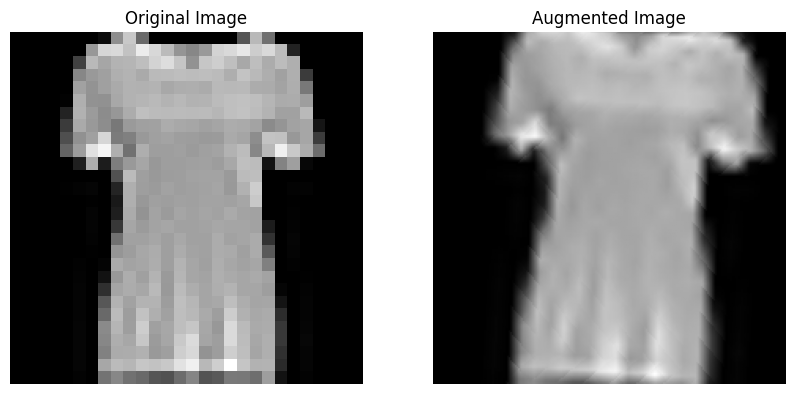

In [42]:
# Function to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), interpolation='none')
    plt.show()

# To see the effect of augmentation, we can apply the transform to a single image multiple times
plain_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transforms.ToTensor())
img, label = plain_dataset[10] # Get the 11th image

# Original Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
# The original image is a tensor, so we convert it to a PIL Image to display
plt.imshow(transforms.ToPILImage()(img), cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Augmented Image
# Apply the training transforms to the original image
augmented_img = transform_train(transforms.ToPILImage()(img))
plt.subplot(1, 2, 2)
# The augmented image is a tensor, we need to permute the dimensions for matplotlib
plt.imshow(augmented_img.permute(1, 2, 0), cmap='gray')
plt.title('Augmented Image')
plt.axis('off')

plt.show()


# Droupout

In [ ]:

net = torchvision.models.resnet18(pretrained=True)

# Modify the first convolutional layer to accept 1 channel (grayscale) instead of 3
net.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Modify the final fully connected layer to output 10 classes for FashionMNIST
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, 10)

# Move the network to the selected device
net.to(device)

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 3. Define a Loss Function and Optimizer


In [44]:
criterion = nn.CrossEntropyLoss()
# Using AdamW optimizer which often performs better
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
# Learning rate scheduler to reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

### 4. Train the Network

In [45]:


# L1 regularization strength
l1_lambda = 1e-5

training_interrupted = False
for epoch in range(10):  # loop over the dataset for more epochs

    running_loss = 0.0
    net.train() # Set model to training mode
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        # Move inputs and labels to the selected device
        inputs, labels = data[0].to(device), data[1].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        try:
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            # Add L1 regularization
            l1_norm = sum(p.abs().sum() for p in net.parameters())
            loss = loss + l1_lambda * l1_norm

            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 100 == 99:    # print every 100 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
                running_loss = 0.0
        except RuntimeError as e:
            print(f"A runtime error occurred: {e}")
            print("This is likely due to the large image size. Please reduce the size in `transforms.Resize`.")
            print("To fix the linear layer size, uncomment `print(x.shape)` in the model's forward pass and update the `fc1` layer.")
            training_interrupted = True
            break
    
    # If the inner loop was broken due to an error, break the outer loop too
    if training_interrupted:
        break

    # Validation step
    val_loss = 0.0
    net.eval() # Set model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    val_loss /= len(testloader)
    print(f'Epoch {epoch + 1}, Validation Loss: {val_loss:.4f}')
    
    # Step the scheduler
    scheduler.step(val_loss)


print('Finished Training (or stopped due to error)')

[1,   100] loss: 2.529
[1,   200] loss: 2.162
[1,   300] loss: 1.962
[1,   400] loss: 1.691
[1,   500] loss: 1.607
[1,   600] loss: 1.476
[1,   700] loss: 1.418
[1,   800] loss: 1.338
[1,   900] loss: 1.253
[1,  1000] loss: 1.217
[1,  1100] loss: 1.170
[1,  1200] loss: 1.139
[1,  1300] loss: 1.088
[1,  1400] loss: 1.043
[1,  1500] loss: 1.032
[1,  1600] loss: 1.025
[1,  1700] loss: 1.001
[1,  1800] loss: 1.025
Epoch 1, Validation Loss: 0.4272
[2,   100] loss: 0.927
[2,   200] loss: 0.900
[2,   300] loss: 0.877
[2,   400] loss: 0.849
[2,   500] loss: 0.836
[2,   600] loss: 0.828
[2,   700] loss: 0.830
[2,   800] loss: 0.817
[2,   900] loss: 0.803
[2,  1000] loss: 0.809
[2,  1100] loss: 0.782
[2,  1200] loss: 0.793
[2,  1300] loss: 0.778
[2,  1400] loss: 0.734
[2,  1500] loss: 0.753
[2,  1600] loss: 0.730
[2,  1700] loss: 0.696
[2,  1800] loss: 0.720
Epoch 2, Validation Loss: 0.3082
[3,   100] loss: 0.680
[3,   200] loss: 0.668
[3,   300] loss: 0.668
[3,   400] loss: 0.656
[3,   500] los

### 5. Test the network on the test data


In [46]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        try:
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        except RuntimeError as e:
            print(f"A runtime error occurred during testing: {e}")
            break

if total > 0:
    print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 92 %
